# Medical Image Processing
Name: Triet Ho Minh

## Import Library

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from skimage.feature import graycomatrix, graycoprops


## Loading image

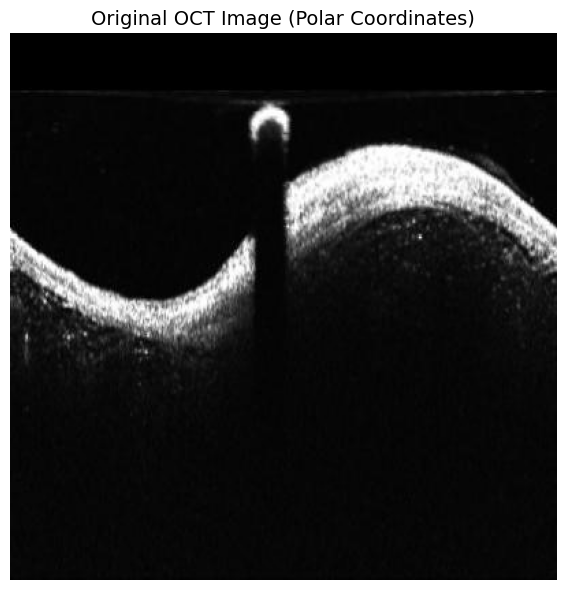

Image shape: (400, 400, 3)


In [2]:
# Load the OCT image
img = cv2.imread('./OCT.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title('Original OCT Image (Polar Coordinates)', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'Image shape: {img.shape}')

## Convert image to grayscale

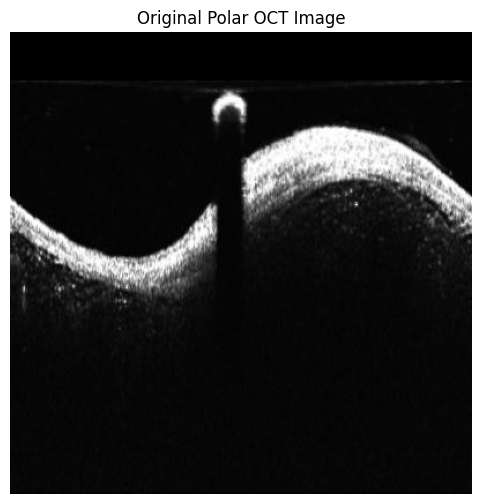

Grayscale shape: (400, 400)
Min pixel value: 0, Max pixel value: 255


In [3]:
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
plt.figure(figsize=(6,6))
plt.imshow(gray, cmap='gray')
plt.title("Original Polar OCT Image")
plt.axis("off")
plt.show()

print(f'Grayscale shape: {gray.shape}')
print(f'Min pixel value: {gray.min()}, Max pixel value: {gray.max()}')

## Image Thresholding

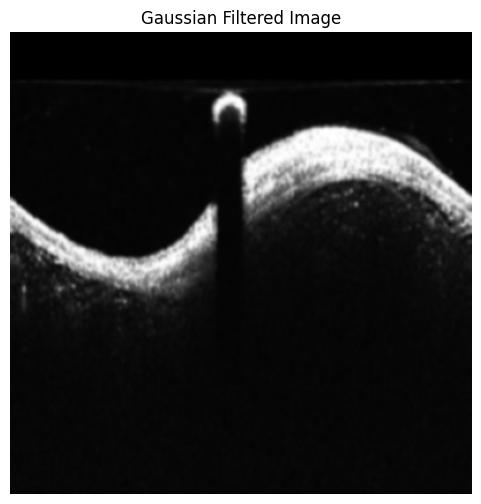

In [4]:
# Before thresholding, apply Gaussian Blur to reduce noise
blur = cv2.GaussianBlur(gray, (5,5), 0)
plt.figure(figsize=(6,6))
plt.imshow(blur, cmap='gray')
plt.title("Gaussian Filtered Image")
plt.axis("off")
plt.show()

(np.float64(-0.5), np.float64(399.5), np.float64(399.5), np.float64(-0.5))

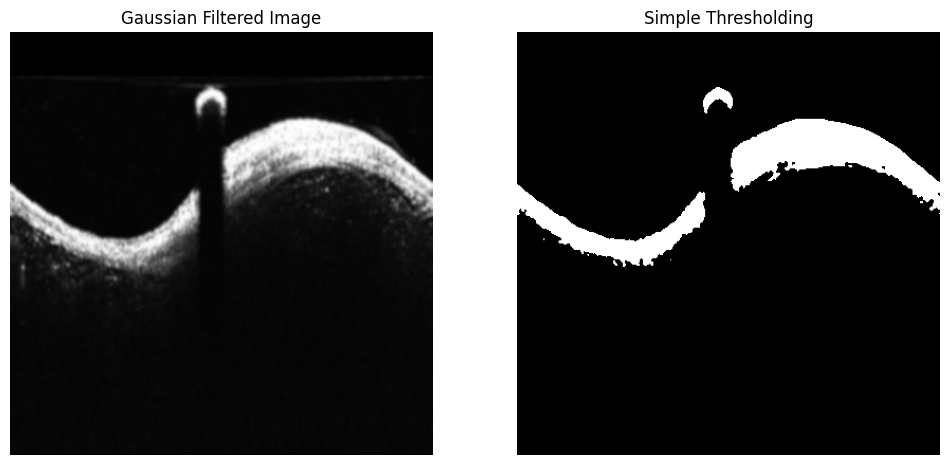

In [5]:
# First, try with normal thresholding
ret, thresh = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY)
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(blur, cmap='gray')
plt.title("Gaussian Filtered Image", fontsize=12)
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(thresh, cmap='gray')
plt.title("Simple Thresholding", fontsize=12)
plt.axis("off")


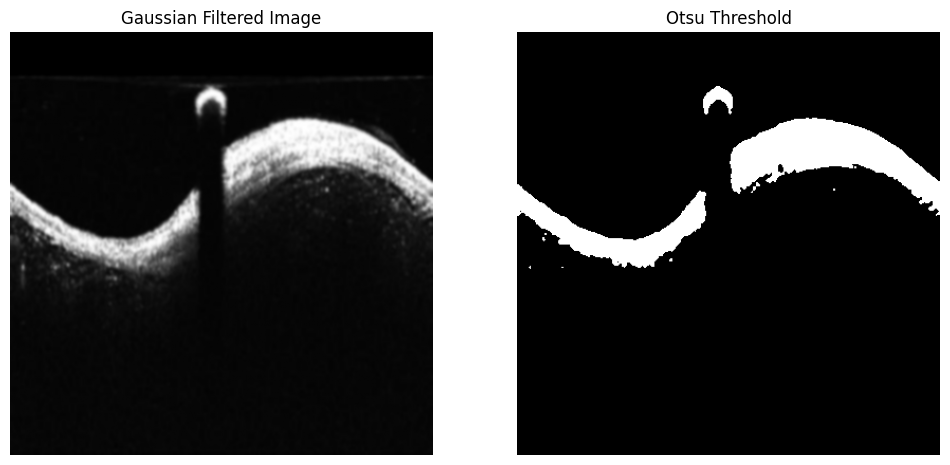

In [6]:
# Otsu thresholding
_, thresh = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(blur, cmap='gray')
plt.title("Gaussian Filtered Image", fontsize=12)
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(thresh, cmap='gray')
plt.title("Otsu Threshold", fontsize=12)
plt.axis("off")
plt.show()

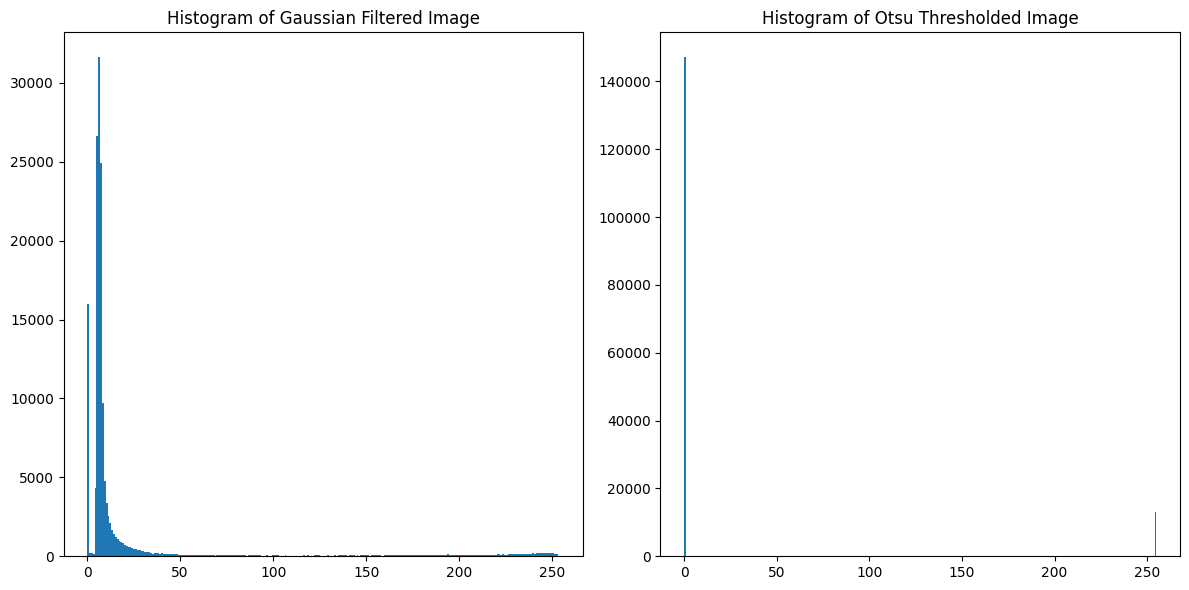

In [7]:
# Showing histogram before and after Otsu thresholding
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.hist(blur.ravel(), bins=256)
plt.title("Histogram of Gaussian Filtered Image", fontsize=12)
plt.subplot(1,2,2)
plt.hist(thresh.ravel(), bins=256)
plt.title("Histogram of Otsu Thresholded Image", fontsize=12)
plt.tight_layout()
plt.show()

## Polar to Cartesian Transformation

### Remove catheter

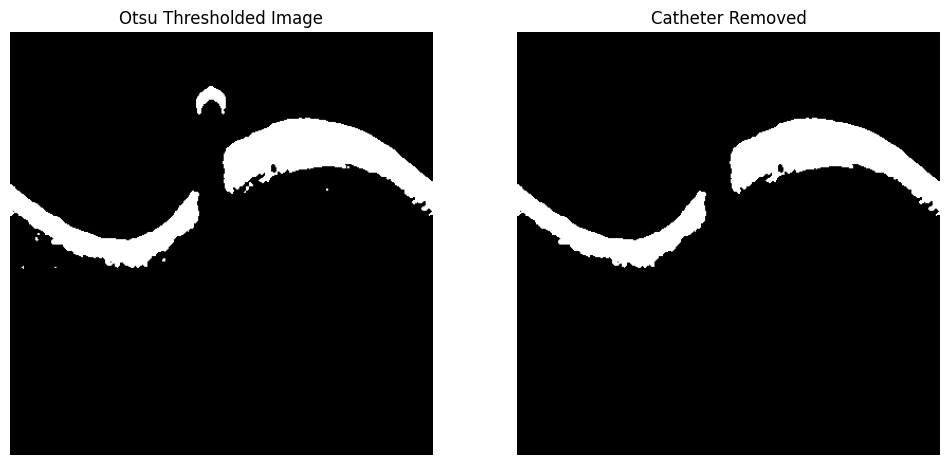

In [8]:
# connected components
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    thresh,
    connectivity=8
)

# create clean image
clean = np.zeros_like(thresh)

# minimum area threshold
min_area = 500

for i in range(1, num_labels):

    area = stats[i, cv2.CC_STAT_AREA]

    if area > min_area:
        clean[labels == i] = 255

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(thresh, cmap='gray')
plt.title("Otsu Thresholded Image")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(clean, cmap='gray')
plt.title("Catheter Removed")
plt.axis("off")
plt.show()

### Detect Lumen Border

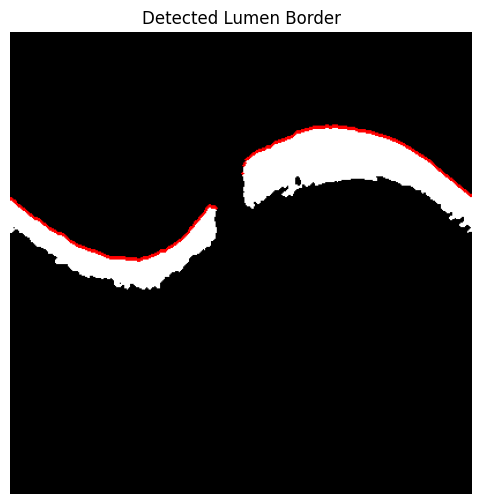

In [9]:
# create contour image
contour_img = cv2.cvtColor(clean, cv2.COLOR_GRAY2RGB)

# save contour points
contour_points = []

# Scan each column top to bottom, save first nonzero pixel, connect nonzero pixels to form the lumen contour
for x in range(clean.shape[1]):
    column = clean[:, x]
    nonzero = np.where(column > 0)[0]
    if len(nonzero) > 0:
        y = nonzero[0]
        contour_points.append((x, y))

# draw contour
for point in contour_points:
    cv2.circle(contour_img, point, 1, (255,0,0), -1)
plt.figure(figsize=(8,6))
plt.imshow(contour_img)
plt.title("Detected Lumen Border")
plt.axis("off")
plt.show()

### Convert Polar to Cartesian Coordinates

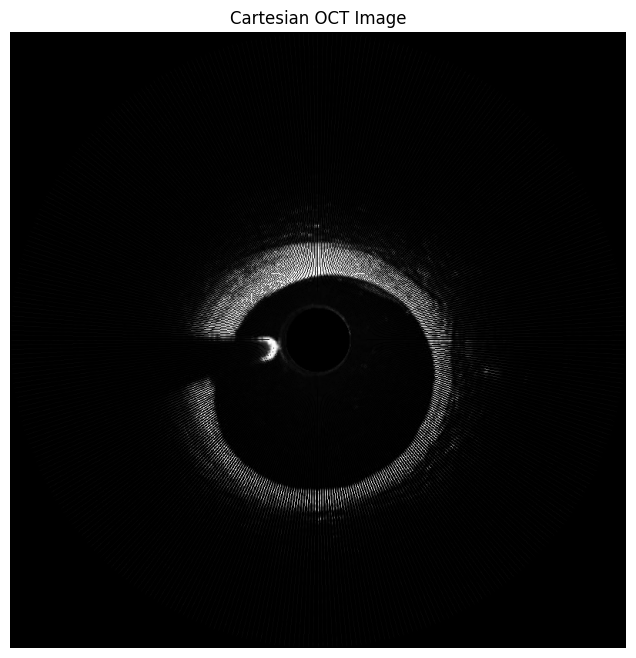

In [11]:
# image dimensions
rows, cols = gray.shape

# output cartesian image
cartesian = np.zeros((rows*2, rows*2), dtype=np.uint8)

# center
center = rows

# convert manually
for theta in range(cols):
    angle = 2 * np.pi * theta / cols
    for r in range(rows):
        x = int(center + r * np.cos(angle))
        y = int(center + r * np.sin(angle))
        if 0 <= x < cartesian.shape[1] and 0 <= y < cartesian.shape[0]:
            cartesian[y, x] = gray[r, theta]

plt.figure(figsize=(8,8))
plt.imshow(cartesian, cmap='gray')
plt.title("Cartesian OCT Image")
plt.axis("off")
plt.show()

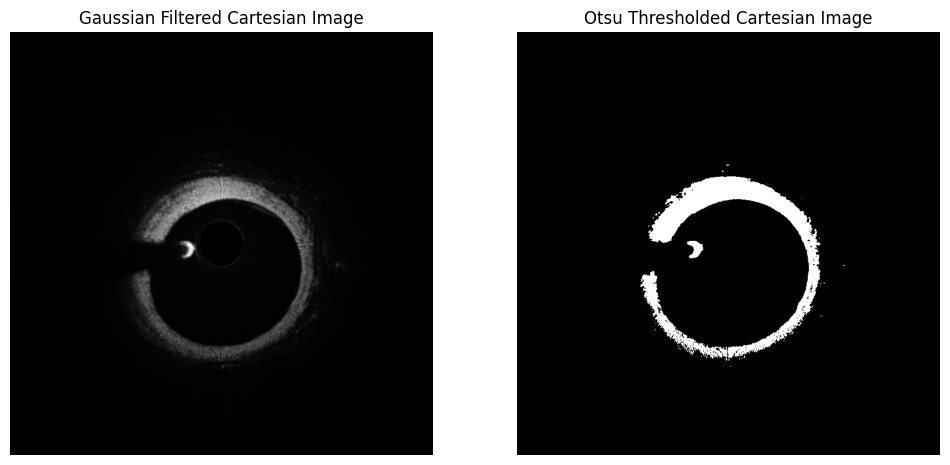

In [12]:
# Thresholding for Cartesian Image
# Apply Gaussian Blur to reduce noise
cart_blur = cv2.GaussianBlur(cartesian, (5,5), 0)
# Otsu thresholding
_, cart_thresh = cv2.threshold(
    cart_blur,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(cart_blur, cmap='gray')
plt.title("Gaussian Filtered Cartesian Image", fontsize=12)
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(cart_thresh, cmap='gray')
plt.title("Otsu Thresholded Cartesian Image", fontsize=12)
plt.axis("off")
plt.show()

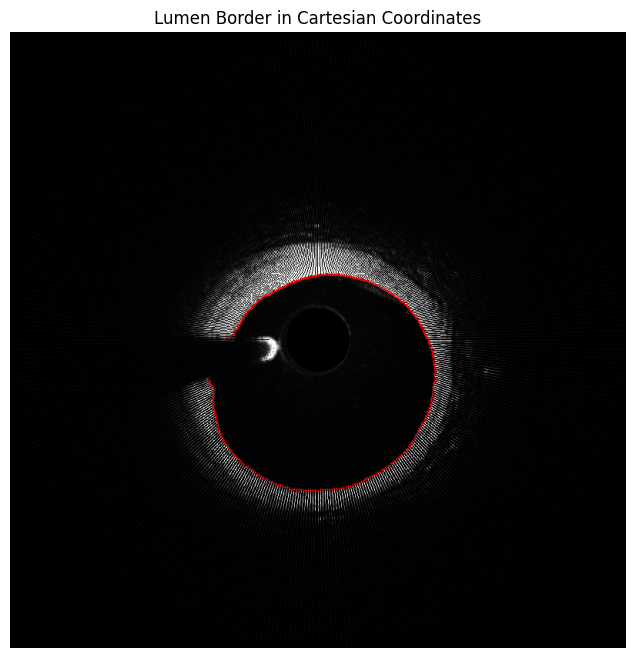

In [13]:
# convert to RGB
cartesian_rgb = cv2.cvtColor(cartesian, cv2.COLOR_GRAY2RGB)

# convert contour points
for (theta, r) in contour_points:

    angle = 2 * np.pi * theta / cols

    x = int(center + r * np.cos(angle))
    y = int(center + r * np.sin(angle))

    cv2.circle(cartesian_rgb, (x,y), 1, (255,0,0), -1)

plt.figure(figsize=(8,8))
plt.imshow(cartesian_rgb)
plt.title("Lumen Border in Cartesian Coordinates")
plt.axis("off")
plt.show()

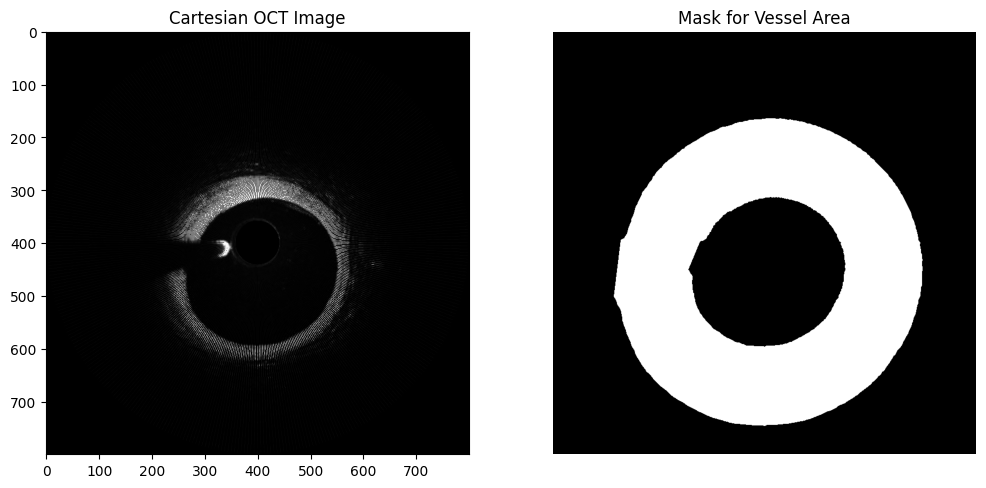

In [14]:
# lumen contour in cartesian coordinates
cartesian_contour = []

for (theta, r) in contour_points:

    angle = 2 * np.pi * theta / cols

    x = int(center + r * np.cos(angle))
    y = int(center + r * np.sin(angle))

    cartesian_contour.append([x, y])

# convert to numpy array
cartesian_contour = np.array(cartesian_contour, dtype=np.int32)
expand_distance = 150

# expand contour
expanded_contour = []

for (theta, r) in contour_points:

    angle = 2 * np.pi * theta / cols

    # expanded radius
    r_expanded = r + expand_distance

    x = int(center + r_expanded * np.cos(angle))
    y = int(center + r_expanded * np.sin(angle))

    expanded_contour.append([x, y])

expanded_contour = np.array(expanded_contour, dtype=np.int32)

# create mask
# empty masks
outer_mask = np.zeros(cartesian.shape, dtype=np.uint8)
inner_mask = np.zeros(cartesian.shape, dtype=np.uint8)

# fill expanded contour
cv2.fillPoly(
    outer_mask,
    [expanded_contour],
    255
)

# fill lumen contour
cv2.fillPoly(
    inner_mask,
    [cartesian_contour],
    255
)

# TA mask = outer - inner
ta_mask = cv2.subtract(outer_mask, inner_mask)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(cartesian, cmap='gray')
plt.title("Cartesian OCT Image")
plt.subplot(1,2,2)
plt.imshow(ta_mask, cmap='gray')
plt.title("Mask for Vessel Area")
plt.axis("off")
plt.show()

## K-means segmentation

In [15]:
# extract pixels inside TA
ta_pixels = cartesian[ta_mask > 0]

# reshape for KMeans
X = ta_pixels.reshape((-1,1))

# convert to float32
X = np.float32(X)

print(X.shape)

(199026, 1)


In [16]:
# KMeans clustering
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans.fit(X)

labels = kmeans.labels_
# cluster centers
centers = kmeans.cluster_centers_.flatten()
print(f'Cluster centers (mean intensity): {centers}')


Cluster centers (mean intensity): [  3.8780327 204.3744   ]


In [17]:
vessel_cluster = np.argmax(centers)
background_cluster = 1 - vessel_cluster

print(f'Vessel cluster index: {vessel_cluster} '
      f'(mean intensity = {centers[vessel_cluster]:.2f})')

print(f'Background cluster index: {background_cluster} '
      f'(mean intensity = {centers[background_cluster]:.2f})')

Vessel cluster index: 1 (mean intensity = 204.37)
Background cluster index: 0 (mean intensity = 3.88)


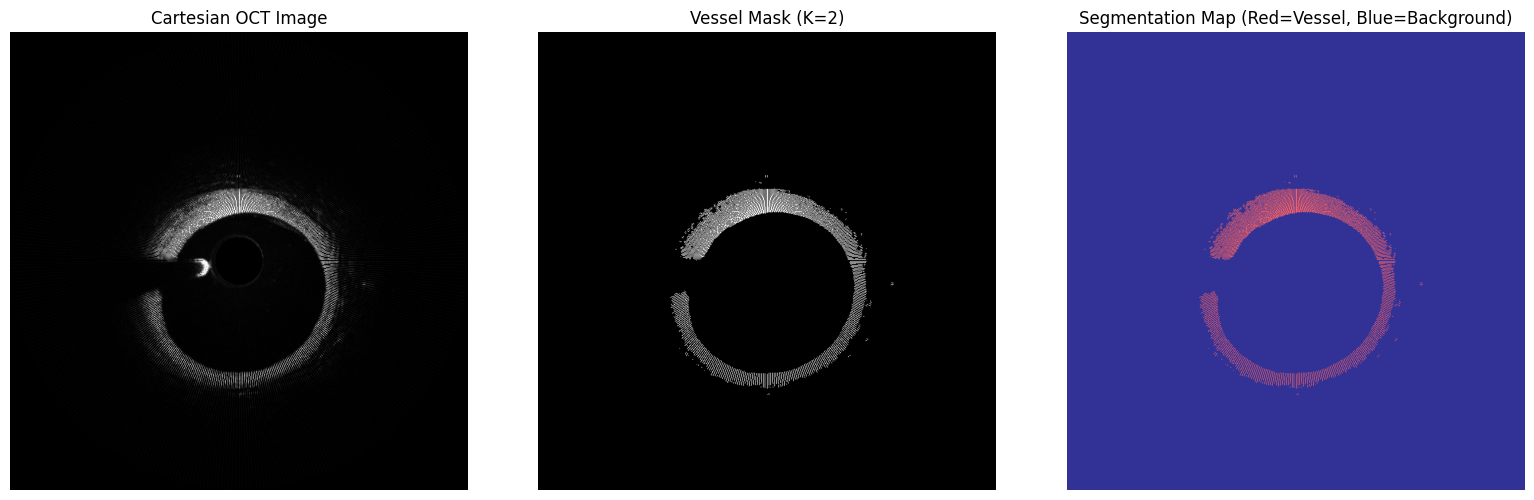

In [18]:
segmented = np.zeros(cartesian.shape, dtype=np.uint8)

# assign labels only inside vessel
segmented[ta_mask > 0] = labels

# Create vessel mask

vessel_mask = np.zeros(cartesian.shape, dtype=np.uint8)

vessel_mask[segmented == vessel_cluster] = 255


segmentation_color = np.zeros((*cartesian.shape, 3),dtype=np.uint8)

# background color
segmentation_color[:] = [50, 50, 150]

# vessel color
segmentation_color[segmented == vessel_cluster] = [255, 100, 100]


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# original image
axes[0].imshow(cartesian, cmap='gray')
axes[0].set_title('Cartesian OCT Image')
axes[0].axis('off')

# vessel mask
axes[1].imshow(vessel_mask, cmap='gray')
axes[1].set_title('Vessel Mask (K=2)')
axes[1].axis('off')

# segmentation map
axes[2].imshow(segmentation_color)
axes[2].set_title('Segmentation Map (Red=Vessel, Blue=Background)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Features Extraction

In [19]:
def extract_features_from_patch(patch):
    mean_val = np.mean(patch)
    std_val = np.std(patch)

    # Quantize patch to 32 levels for GLCM efficiency
    patch_q = (patch / 8).astype(np.uint8)

    glcm = graycomatrix(
        patch_q, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=32, symmetric=True, normed=True
    )

    contrast = graycoprops(glcm, 'contrast').mean()
    correlation = graycoprops(glcm, 'correlation').mean()
    energy = graycoprops(glcm, 'energy').mean()
    homogeneity = graycoprops(glcm, 'homogeneity').mean()

    return [mean_val, std_val, contrast, correlation, energy, homogeneity]


def extract_all_features(image, mask_size=11, sample_step=4):
    pad = mask_size // 2
    img_padded = cv2.copyMakeBorder(image, pad, pad, pad, pad, cv2.BORDER_REFLECT)

    h, w = image.shape
    features = []
    coords = []

    for y in range(0, h, sample_step):
        for x in range(0, w, sample_step):
            patch = img_padded[y:y + mask_size, x:x + mask_size]
            feat = extract_features_from_patch(patch)
            features.append(feat)
            coords.append((y, x))

    return np.array(features), coords

features, coords = extract_all_features(cartesian, mask_size=11, sample_step=4)
print(f'Feature matrix shape: {features.shape}')
print(f'Features: [mean, std, contrast, correlation, energy, homogeneity]')

Feature matrix shape: (40000, 6)
Features: [mean, std, contrast, correlation, energy, homogeneity]


In [20]:
# Collect labels for the sampled pixels from K-Means segmentation
pixel_labels = []
for (y, x) in coords:
    pixel_labels.append(segmented[y, x])

pixel_labels = np.array(pixel_labels)

# Map to: 1 = vessel, 0 = background
class_labels = (pixel_labels == vessel_cluster).astype(int)

n_vessel = np.sum(class_labels == 1)
n_background = np.sum(class_labels == 0)
print(f'Vessel pixels sampled: {n_vessel}')
print(f'Background pixels sampled: {n_background}')

Vessel pixels sampled: 729
Background pixels sampled: 39271


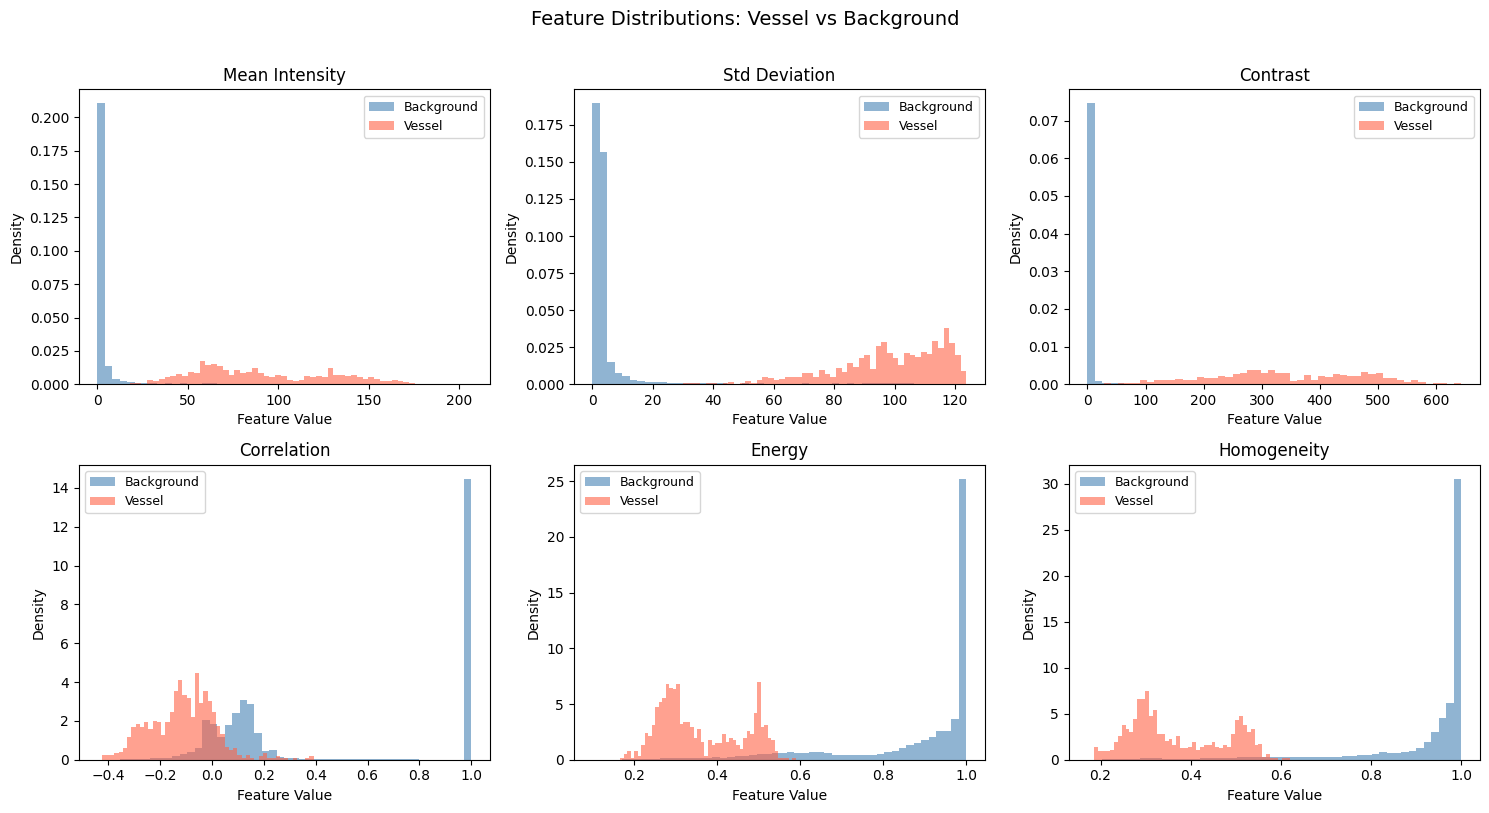

In [21]:
feature_names = ['Mean Intensity', 'Std Deviation', 'Contrast', 'Correlation', 'Energy', 'Homogeneity']

vessel_feats = features[class_labels == 1]
background_feats = features[class_labels == 0]

# Plot histograms for each feature, vessel vs background
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, name in enumerate(feature_names):
    axes[i].hist(background_feats[:, i], bins=50, alpha=0.6,
                 color='steelblue', label='Background', density=True)
    axes[i].hist(vessel_feats[:, i], bins=50, alpha=0.6,
                 color='tomato', label='Vessel', density=True)
    axes[i].set_title(name, fontsize=12)
    axes[i].set_xlabel('Feature Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)

plt.suptitle('Feature Distributions: Vessel vs Background', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

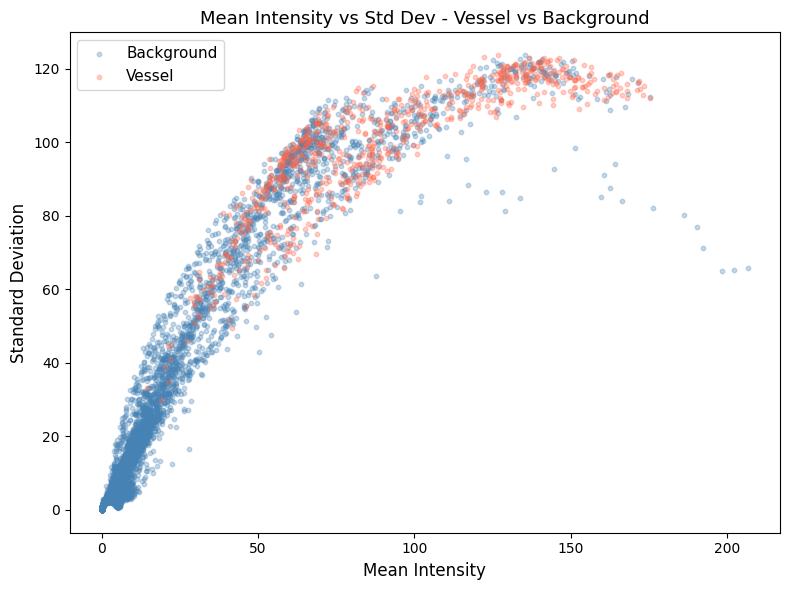

In [22]:
# 2D scatter plot: Mean intensity vs Std Deviation
plt.figure(figsize=(8, 6))
plt.scatter(background_feats[:, 0], background_feats[:, 1],
            c='steelblue', alpha=0.3, s=10, label='Background')
plt.scatter(vessel_feats[:, 0], vessel_feats[:, 1],
            c='tomato', alpha=0.3, s=10, label='Vessel')
plt.xlabel('Mean Intensity', fontsize=12)
plt.ylabel('Standard Deviation', fontsize=12)
plt.title('Mean Intensity vs Std Dev - Vessel vs Background', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

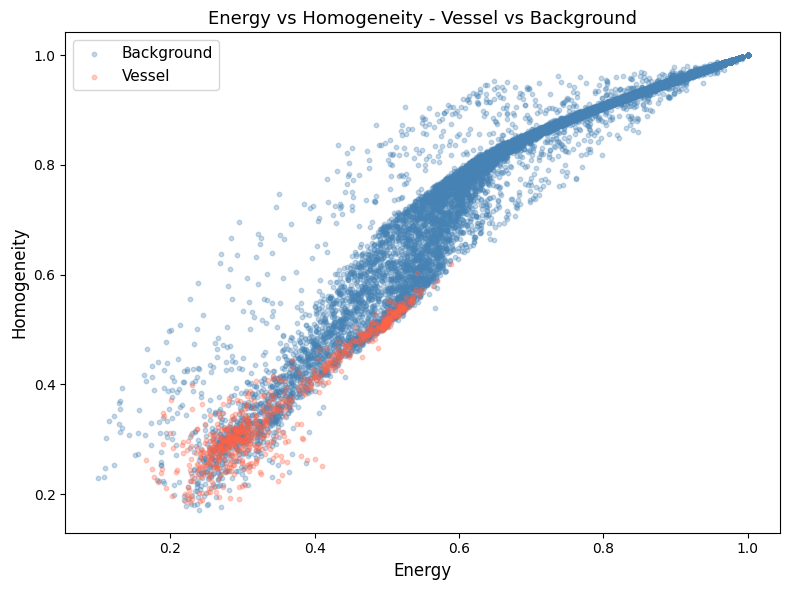

In [23]:
# 2D scatter plot: Energy vs Homogeneity
plt.figure(figsize=(8, 6))
plt.scatter(background_feats[:, 4], background_feats[:, 5],
            c='steelblue', alpha=0.3, s=10, label='Background')
plt.scatter(vessel_feats[:, 4], vessel_feats[:, 5],
            c='tomato', alpha=0.3, s=10, label='Vessel')
plt.xlabel('Energy', fontsize=12)
plt.ylabel('Homogeneity', fontsize=12)
plt.title('Energy vs Homogeneity - Vessel vs Background', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_16448\717700344.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_to_plot, patch_artist=True,
C:\Users\Admin\AppData\Local\Temp\ipykernel_16448\717700344.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_to_plot, patch_artist=True,
C:\Users\Admin\AppData\Local\Temp\ipykernel_16448\717700344.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_to_plot, patch_artist=True,
C:\Users\Admin\AppData\Local\Temp\ipykernel_16448\717700344.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxpl

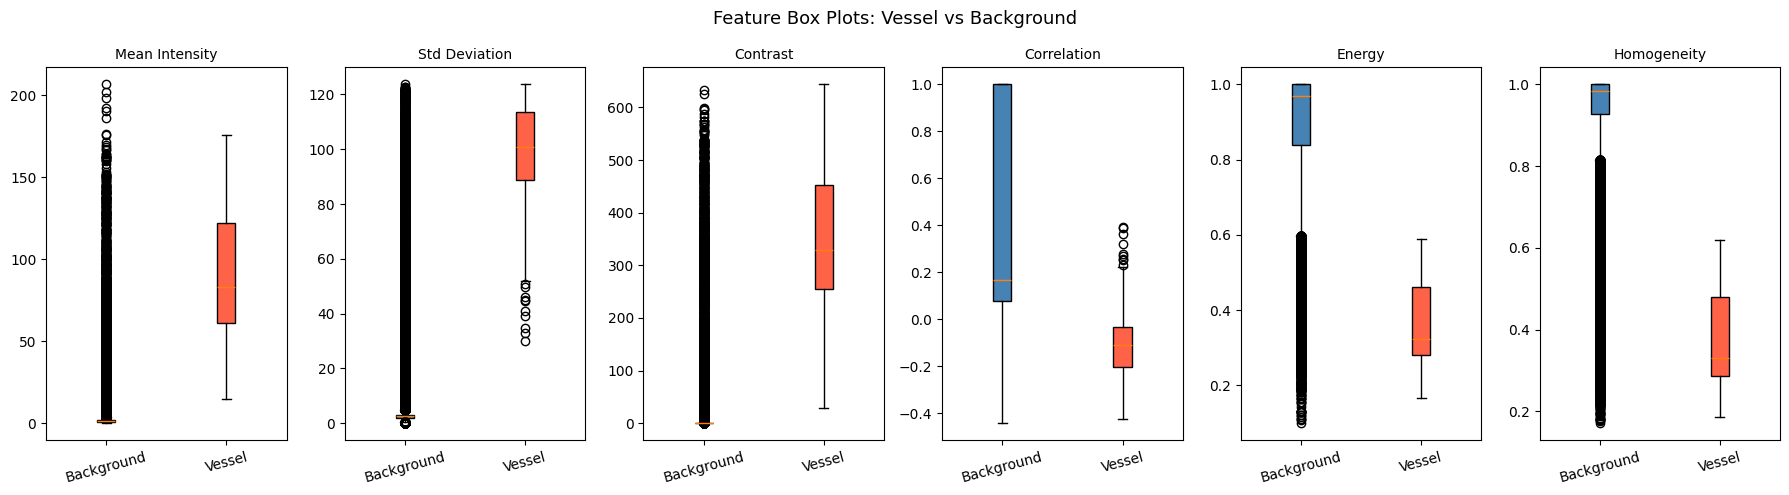


Mean feature values per class:
Feature                   Background          Vessel
----------------------------------------------------
Mean Intensity                4.2716         90.1543
Std Deviation                 6.2317         98.3098
Contrast                      9.4915        340.9117
Correlation                   0.4674         -0.1125
Energy                        0.8785          0.3584
Homogeneity                   0.9193          0.3695


In [24]:
# Box plots for all features
fig, axes = plt.subplots(1, 6, figsize=(18, 5))

for i, name in enumerate(feature_names):
    data_to_plot = [background_feats[:, i], vessel_feats[:, i]]
    bp = axes[i].boxplot(data_to_plot, patch_artist=True,
                         labels=['Background', 'Vessel'])
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('tomato')
    axes[i].set_title(name, fontsize=10)
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Feature Box Plots: Vessel vs Background', fontsize=13)
plt.tight_layout()
plt.show()

print('\nMean feature values per class:')
print(f'{"Feature":<20} {"Background":>15} {"Vessel":>15}')
print('-' * 52)
for i, name in enumerate(feature_names):
    print(f'{name:<20} {background_feats[:, i].mean():>15.4f} {vessel_feats[:, i].mean():>15.4f}')

## Machine Learning - Separating pixels into 2 classes

### Random forest

In [25]:
# split dataset
X_train, X_test, y_train, y_test = train_test_split(
    features,
    class_labels,
    test_size=0.2,
    random_state=42
)

# classifier
rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train, y_train)

# prediction
y_pred = rf.predict(X_test)

# accuracy
acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Background', 'Vessel']))

Accuracy: 0.98325

Classification Report:
              precision    recall  f1-score   support

  Background       0.99      0.99      0.99      7858
      Vessel       0.54      0.41      0.46       142

    accuracy                           0.98      8000
   macro avg       0.76      0.70      0.73      8000
weighted avg       0.98      0.98      0.98      8000



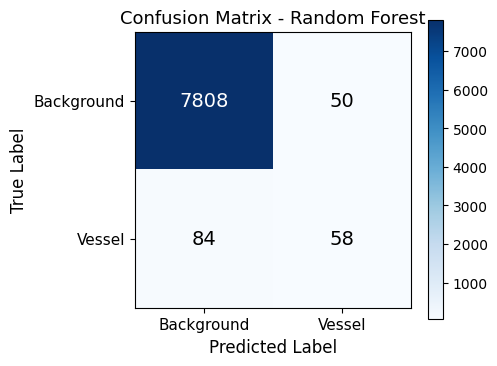

In [26]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks([0, 1], ['Background', 'Vessel'], fontsize=11)
plt.yticks([0, 1], ['Background', 'Vessel'], fontsize=11)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Random Forest', fontsize=13)

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center',
                 fontsize=14, color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.tight_layout()
plt.show()


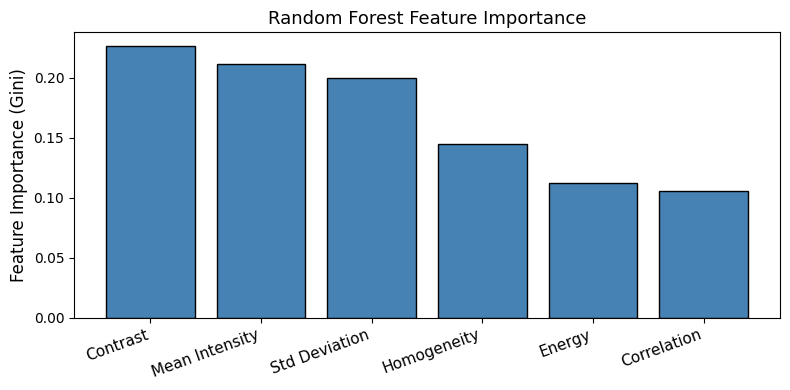

Contrast            : 0.2264
Mean Intensity      : 0.2111
Std Deviation       : 0.1996
Homogeneity         : 0.1447
Energy              : 0.1126
Correlation         : 0.1056


In [27]:
# Feature importance
importances = rf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 4))
plt.bar(range(len(feature_names)),
        importances[sorted_idx],
        color='steelblue', edgecolor='black')
plt.xticks(range(len(feature_names)),
           [feature_names[i] for i in sorted_idx],
           rotation=20, ha='right', fontsize=11)
plt.ylabel('Feature Importance (Gini)', fontsize=12)
plt.title('Random Forest Feature Importance', fontsize=13)
plt.tight_layout()
plt.show()

for i in sorted_idx:
    print(f'{feature_names[i]:<20}: {importances[i]:.4f}')

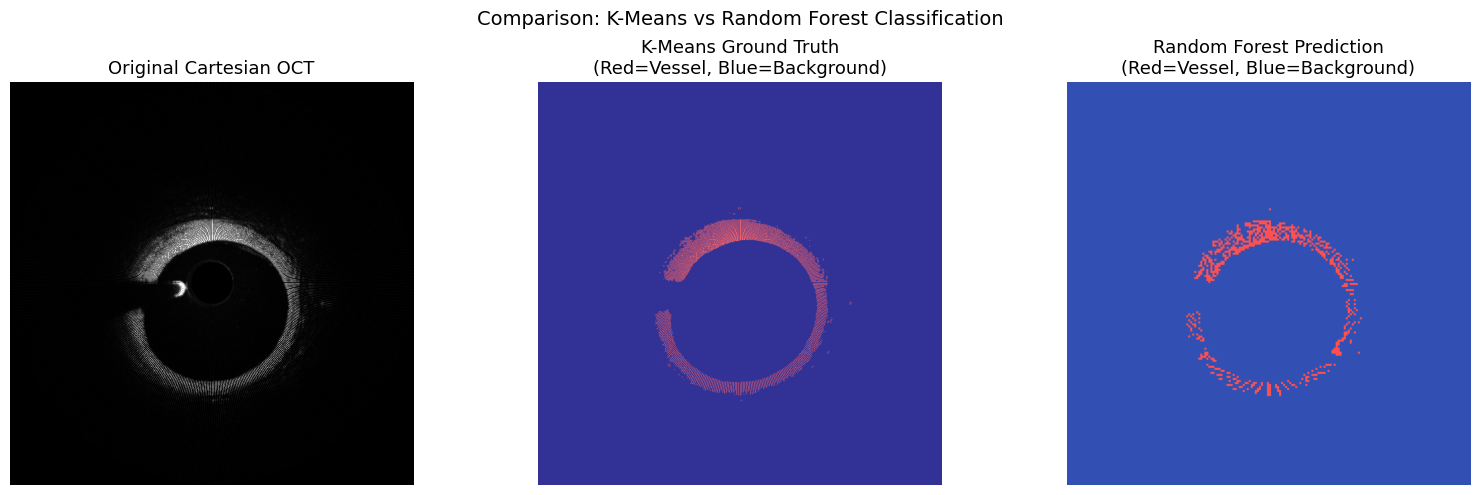

In [28]:
# Generate prediction map for the full image
all_predictions = rf.predict(features)

# Reconstruct prediction image
h, w = cartesian.shape
pred_map = np.zeros((h, w), dtype=np.uint8)

for idx, (y, x) in enumerate(coords):
    y_end = min(y + 4, h)
    x_end = min(x + 4, w)
    pred_map[y:y_end, x:x_end] = all_predictions[idx]

# Color-coded prediction map
pred_color = np.zeros((h, w, 3), dtype=np.uint8)
pred_color[pred_map == 1] = [255, 80, 80]   # red for vessel
pred_color[pred_map == 0] = [50, 80, 180]   # blue for background

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(cartesian, cmap='gray')
axes[0].set_title('Original Cartesian OCT', fontsize=13)
axes[0].axis('off')

axes[1].imshow(segmentation_color)
axes[1].set_title('K-Means Ground Truth\n(Red=Vessel, Blue=Background)', fontsize=13)
axes[1].axis('off')

axes[2].imshow(pred_color)
axes[2].set_title('Random Forest Prediction\n(Red=Vessel, Blue=Background)', fontsize=13)
axes[2].axis('off')

plt.suptitle('Comparison: K-Means vs Random Forest Classification', fontsize=14)
plt.tight_layout()
plt.show()